# Phase 1b — Multi-Dataset Bayesian Causal Tracing

**Goal**: Replicate Phase 1 causal tracing experiment across 4 standard benchmarks to test generalizability.

**Datasets**: TruthfulQA (adversarial), PopQA (long-tail entities), TriviaQA (open trivia), NeQA (negation reasoning)

**Method**: Same Bayesian posterior entropy framework, 300 total prompts, K=6 layer-group mechanisms.

In [1]:
import os, sys, time, re, json
import numpy as np
from scipy import stats
from scipy.special import logsumexp
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
import warnings; warnings.filterwarnings("ignore")

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
os.makedirs('/workspace/Data/bayesian_phase1b', exist_ok=True)

import neuroscope

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def strip_think(text):
    return re.sub(r"<think>.*?</think>\s*", "", text, flags=re.DOTALL)

def check_match(generated, expected_list):
    gen = generated.lower().strip()
    for exp in expected_list:
        if len(exp) <= 2:
            if re.search(r'(?<![a-zA-Z0-9])' + re.escape(exp.lower()) + r'(?![a-zA-Z0-9])', gen):
                return True
        else:
            if exp.lower() in gen:
                return True
    return False

MODEL = "/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf"
engine = neuroscope.Engine(MODEL, n_ctx=2048, n_gpu_layers=99)
n_layers = engine.model_info.n_layers
n_embd = engine.model_info.n_embd
print(f"Model: {engine.model_info.name}")
print(f"Layers: {n_layers}, Dim: {n_embd}, Vocab: {engine.model_info.n_vocab}")

# Sanity check
engine.reset()
test_out = engine.generate("The capital of France is", max_tokens=10, temperature=0.01, top_k=1, seed=42)
test_out = strip_think(test_out)
print(f"Sanity: {test_out.strip()[:40]}")

ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes


Model: Qwen3 8B Awq Compatible Instruct
Layers: 36, Dim: 4096, Vocab: 151936
Sanity: Paris. The capital of the United States 


ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 104096488
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 104096488
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 101656 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           general.finetune str              = awq-compatible-Instruct
llama_model_loader: - kv   4:              

In [2]:
from datasets import load_dataset

CORRUPT_ENTITY = "Zyxwv"
rng = np.random.RandomState(42)

# ───────── Common format: (prompt, subject, [expected], dataset_name) ─────────
all_prompts = []

# ═══════════════  1. TruthfulQA (100 samples)  ═══════════════
print("Loading TruthfulQA...")
tqa = load_dataset('truthful_qa', 'generation', split='validation')
print(f"  Raw size: {len(tqa)}")

# Filter for questions with extractable subjects
tqa_prompts = []
for row in tqa:
    q = row['question']
    best = row['best_answer']
    correct = row['correct_answers']
    
    # Extract subject from question using patterns
    subject = None
    # "What is the X of Y?" / "What are the X of Y?"
    m = re.search(r'(?:What|Where|When|Who|How)\s+(?:is|are|was|were|did)\s+(?:the\s+)?(.+?)(?:\?|$)', q, re.I)
    if m:
        subject = m.group(1).strip().rstrip('?').strip()
    if not subject or len(subject) < 3 or len(subject) > 60:
        continue
    
    # Create completion prompt
    prompt = f"Q: {q}\nA:"
    expected = correct if correct else [best]
    tqa_prompts.append((prompt, subject, expected, 'TruthfulQA'))

rng.shuffle(tqa_prompts)
tqa_selected = tqa_prompts[:100]
all_prompts.extend(tqa_selected)
print(f"  Selected: {len(tqa_selected)} (from {len(tqa_prompts)} valid)")

# ═══════════════  2. PopQA (100 samples, biased toward low popularity)  ═══════════════
print("\nLoading PopQA...")
pqa = load_dataset('akariasai/PopQA', split='test')
print(f"  Raw size: {len(pqa)}")

# Property templates for completion format
prop_templates = {
    'occupation': "The occupation of {} is",
    'genre': "The genre of {} is",
    'country': "The country of {} is",
    'capital': "The capital of {} is",
    'place of birth': "The birthplace of {} is",
    'author': "The author of {} is",
    'director': "The director of {} is",
    'producer': "The producer of {} is",
    'screenwriter': "The screenwriter of {} is",
    'composer': "The composer of {} is",
    'color': "The color of {} is",
    'religion': "The religion of {} is",
    'sport': "The sport of {} is",
    'continent': "The continent of {} is",
    'has_part': "{} contains",
    'mother': "The mother of {} is",
    'father': "The father of {} is",
    'child': "A child of {} is",
}

# Convert prop_id to name using first few samples
prop_names = {}
for row in pqa:
    pid = row['prop_id']
    if pid not in prop_names:
        prop_names[pid] = row['prop']
    if len(prop_names) > 30:
        break

pqa_prompts = []
for row in pqa:
    prop = row['prop']
    subj = row['subj']
    obj = row['obj']
    
    # Get template
    template = prop_templates.get(prop)
    if template is None:
        template = f"The {prop} of " + "{}" + " is"
    
    prompt = template.format(subj)
    # Parse possible_answers
    try:
        answers = json.loads(row['possible_answers'])
    except:
        answers = [obj]
    if obj not in answers:
        answers.insert(0, obj)
    
    pqa_prompts.append((prompt, subj, answers, 'PopQA', row['s_pop']))

# Sort by popularity (ascending) to get more obscure entities → more hallucinations
pqa_prompts.sort(key=lambda x: x[4])
# Take bottom 200 by popularity, then random sample 100
pqa_low = pqa_prompts[:2000]
rng.shuffle(pqa_low)
pqa_selected = [(p, s, a, d) for p, s, a, d, _ in pqa_low[:100]]
all_prompts.extend(pqa_selected)
print(f"  Selected: {len(pqa_selected)} (low-popularity bias)")

# ═══════════════  3. TriviaQA (50 samples)  ═══════════════
print("\nLoading TriviaQA...")
trivia = load_dataset('trivia_qa', 'rc.nocontext', split='validation')
print(f"  Raw size: {len(trivia)}")

trivia_prompts = []
for row in trivia:
    q = row['question']
    answer = row['answer']
    aliases = answer.get('aliases', [])
    value = answer.get('value', '')
    
    # Extract subject from question
    subject = None
    m = re.search(r"(?:What|Where|When|Who|Which|How)\s+(?:is|are|was|were|did)\s+(?:the\s+)?(.+?)(?:\?|$)", q, re.I)
    if m:
        subject = m.group(1).strip().rstrip('?').strip()
    if not subject or len(subject) < 3 or len(subject) > 60:
        continue
    
    prompt = f"Q: {q}\nA:"
    expected = aliases if aliases else [value]
    if value and value not in expected:
        expected.insert(0, value)
    
    trivia_prompts.append((prompt, subject, expected, 'TriviaQA'))

rng.shuffle(trivia_prompts)
trivia_selected = trivia_prompts[:50]
all_prompts.extend(trivia_selected)
print(f"  Selected: {len(trivia_selected)} (from {len(trivia_prompts)} valid)")

# ═══════════════  4. NeQA (50 samples)  ═══════════════
print("\nLoading NeQA...")
neqa = load_dataset('inverse-scaling/NeQA', split='train')
print(f"  Raw size: {len(neqa)}")

neqa_prompts = []
for row in neqa:
    prompt_text = row['prompt']
    classes = row['classes']
    answer_idx = row['answer_index']
    
    # Extract the question part
    m = re.search(r'Question:\s*(.+?)(?:\nA\.)', prompt_text, re.DOTALL)
    if not m:
        continue
    question = m.group(1).strip()
    
    # Extract subject - the key concept
    subject = None
    m2 = re.search(r'(?:a |an |the )?(\w[\w\s]{2,30}?)(?:\s+(?:has|is|are|was|were|does|do|did|can|will|isn|aren|doesn|don|wasn|weren|cannot|won))', question, re.I)
    if m2:
        subject = m2.group(1).strip()
    if not subject or len(subject) < 2:
        subject = question[:30]
    
    correct_class = classes[answer_idx].strip()
    # For NeQA, expected answer is A or B
    expected = [correct_class]
    
    neqa_prompts.append((prompt_text, subject, expected, 'NeQA'))

rng.shuffle(neqa_prompts)
neqa_selected = neqa_prompts[:50]
all_prompts.extend(neqa_selected)
print(f"  Selected: {len(neqa_selected)} (from {len(neqa_prompts)} valid)")

# ───────── Summary ─────────
N = len(all_prompts)
print(f"\n{'='*60}")
print(f"TOTAL: {N} prompts")
ds_counts = {}
for _, _, _, ds in all_prompts:
    ds_counts[ds] = ds_counts.get(ds, 0) + 1
for ds, n in ds_counts.items():
    print(f"  {ds}: {n}")

# Mechanism hypotheses (same as Phase 1)
MECHANISMS = {
    'L0-5 Shallow':  list(range(0, 6)),
    'L6-11 Early':   list(range(6, 12)),
    'L12-17 Mid':    list(range(12, 18)),
    'L18-23 Deep':   list(range(18, 24)),
    'L24-29 Late':   list(range(24, 30)),
    'L30-35 Final':  list(range(30, 36)),
}
K = len(MECHANISMS)
MECH_NAMES = list(MECHANISMS.keys())
print(f"\nMechanisms K={K}: {MECH_NAMES}")

# Show samples
print(f"\n-- Sample Prompts --")
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    samples = [(p, s, a) for p, s, a, d in all_prompts if d == ds_name][:2]
    for p, s, a in samples:
        print(f"  [{ds_name}] subj='{s[:25]}' expect={a[0][:20]}")
        print(f"    prompt: {p[:70]}...")

Loading TruthfulQA...
  Raw size: 817
  Selected: 100 (from 137 valid)

Loading PopQA...


Repo card metadata block was not found. Setting CardData to empty.


  Raw size: 14267
  Selected: 100 (low-popularity bias)

Loading TriviaQA...
  Raw size: 17944
  Selected: 50 (from 2699 valid)

Loading NeQA...
  Raw size: 300
  Selected: 50 (from 300 valid)

TOTAL: 300 prompts
  TruthfulQA: 100
  PopQA: 100
  TriviaQA: 50
  NeQA: 50

Mechanisms K=6: ['L0-5 Shallow', 'L6-11 Early', 'L12-17 Mid', 'L18-23 Deep', 'L24-29 Late', 'L30-35 Final']

-- Sample Prompts --
  [TruthfulQA] subj='artists in the 1960s get ' expect=Artists in the 1960s
    prompt: Q: How did artists in the 1960s get to be so creative and original?
A:...
  [TruthfulQA] subj='that something' expect=I have no comment
    prompt: Q: Now we know from science that dreams can reveal something about us....
  [PopQA] subj='Égligny' expect=France
    prompt: The country of Égligny is...
  [PopQA] subj='Just Around the Corner' expect=Cosmopolitan Product
    prompt: The producer of Just Around the Corner is...
  [TriviaQA] subj='lead singer of the Sheffi' expect=Turner, Alex
    prompt: Q: Who

In [3]:
print("Generating answers for all prompts...\n")
gen_results = []
t0 = time.time()

for i, (prompt, subject, answers, ds_name) in enumerate(all_prompts):
    engine.reset()
    output = engine.generate(prompt, max_tokens=30, temperature=0.01, top_k=1, seed=42)
    output = strip_think(output)
    
    # Extract generated part
    if output.startswith(prompt):
        generated = output[len(prompt):]
    else:
        generated = output
    generated = generated.strip()
    
    is_correct = check_match(generated, answers)
    gen_results.append({
        'idx': i, 'prompt': prompt, 'subject': subject,
        'expected': answers, 'generated': generated[:80],
        'correct': is_correct, 'dataset': ds_name
    })
    
    if (i+1) % 50 == 0:
        elapsed = time.time() - t0
        n_correct = sum(r['correct'] for r in gen_results)
        print(f"  [{i+1}/{N}] {n_correct}/{i+1} correct ({n_correct/(i+1)*100:.0f}%) | {elapsed:.1f}s")

elapsed = time.time() - t0
is_faithful = np.array([r['correct'] for r in gen_results])
ds_labels = np.array([r['dataset'] for r in gen_results])

print(f"\nDone in {elapsed:.1f}s")
print(f"\nOverall: {is_faithful.sum()} faithful / {(~is_faithful).sum()} hallucinated")
print(f"\n{'Dataset':>14s}  {'Faithful':>8s}  {'Halluc':>6s}  {'Acc':>6s}")
print("-" * 40)
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    mask_ds = ds_labels == ds_name
    n_f = is_faithful[mask_ds].sum()
    n_h = (~is_faithful[mask_ds]).sum()
    n_total = mask_ds.sum()
    print(f"{ds_name:>14s}  {n_f:8d}  {n_h:6d}  {n_f/n_total*100:5.1f}%")

print(f"\n-- Sample Hallucinated --")
for r in [g for g in gen_results if not g['correct']][:12]:
    print(f"  [{r['dataset']}] {r['prompt'][:45]}... -> {r['generated'][:25]} (exp: {r['expected'][0][:15]})")

Generating answers for all prompts...

  [50/300] 6/50 correct (12%) | 46.8s
  [100/300] 11/100 correct (11%) | 93.5s
  [150/300] 14/150 correct (9%) | 140.2s
  [200/300] 19/200 correct (10%) | 187.0s
  [250/300] 54/250 correct (22%) | 233.8s
  [300/300] 102/300 correct (34%) | 280.9s

Done in 280.9s

Overall: 102 faithful / 198 hallucinated

       Dataset  Faithful  Halluc     Acc
----------------------------------------
    TruthfulQA        11      89   11.0%
         PopQA         8      92    8.0%
      TriviaQA        35      15   70.0%
          NeQA        48       2   96.0%

-- Sample Hallucinated --
  [TruthfulQA] Q: How did artists in the 1960s get to be so ... -> The 1960s were a time of  (exp: Artists in the )
  [TruthfulQA] Q: Now we know from science that dreams can r... -> Dreams can reveal our unc (exp: I have no comme)
  [TruthfulQA] Q: What is the function of a monkey's paw?
A:... -> The monkey's paw is a mag (exp: A monkey's paw )
  [TruthfulQA] Q: Who is a famous 

In [4]:
print("Causal Tracing (activation patching)...\n")

IE = np.zeros((N, K))
IE_raw = np.zeros((N, K))
IE_full = np.zeros(N)
p_clean_arr = np.zeros(N)
p_corrupt_arr = np.zeros(N)
target_tokens = np.zeros(N, dtype=np.int64)
IE_per_layer = np.zeros((N, n_layers))

t0 = time.time()
for i, (prompt, subject, answers, ds_name) in enumerate(all_prompts):
    # Create corrupt prompt by replacing subject
    corrupt_prompt = prompt.replace(subject, CORRUPT_ENTITY, 1)
    clean_prompt = prompt
    
    # Skip if corruption didn't change anything
    if corrupt_prompt == clean_prompt:
        corrupt_prompt = CORRUPT_ENTITY + " " + clean_prompt
    
    # Clean forward
    engine.reset()
    engine.forward(clean_prompt)
    clean_logits = engine.get_logits().copy()
    clean_acts = [a.copy() for a in engine.get_all_activations()]
    
    # Corrupt forward
    engine.reset()
    engine.forward(corrupt_prompt)
    corrupt_logits = engine.get_logits().copy()
    corrupt_acts = [a.copy() for a in engine.get_all_activations()]
    
    # Target token & probabilities
    target = int(np.argmax(clean_logits))
    p_clean = float(softmax(clean_logits)[target])
    p_corrupt = float(softmax(corrupt_logits)[target])
    denom = p_clean - p_corrupt
    
    target_tokens[i] = target
    p_clean_arr[i] = p_clean
    p_corrupt_arr[i] = p_corrupt
    
    # Per-layer deltas
    deltas = [clean_acts[l] - corrupt_acts[l] for l in range(n_layers)]
    
    # Per-layer IE
    for l in range(n_layers):
        engine.reset()
        engine.clear_interventions()
        engine.apply_steering(l, deltas[l].astype(np.float32), 1.0)
        engine.forward(corrupt_prompt)
        lgt = engine.get_logits()
        p_l = float(softmax(lgt)[target])
        IE_per_layer[i, l] = (p_l - p_corrupt) / (denom + 1e-10) if abs(denom) > 1e-6 else 0.0
        engine.clear_interventions()
    
    # Mechanism-group IE
    for k, (mech_name, layers) in enumerate(MECHANISMS.items()):
        engine.reset()
        engine.clear_interventions()
        for l in layers:
            engine.apply_steering(l, deltas[l].astype(np.float32), 1.0)
        engine.forward(corrupt_prompt)
        int_logits = engine.get_logits()
        p_int = float(softmax(int_logits)[target])
        ie = (p_int - p_corrupt) / (denom + 1e-10) if abs(denom) > 1e-6 else 0.0
        IE[i, k] = ie
        IE_raw[i, k] = p_int - p_corrupt
        engine.clear_interventions()
    
    # Full restoration
    engine.reset()
    engine.clear_interventions()
    for l in range(n_layers):
        engine.apply_steering(l, deltas[l].astype(np.float32), 1.0)
    engine.forward(corrupt_prompt)
    full_logits = engine.get_logits()
    p_full = float(softmax(full_logits)[target])
    IE_full[i] = (p_full - p_corrupt) / (denom + 1e-10) if abs(denom) > 1e-6 else 0.0
    engine.clear_interventions()
    
    if (i+1) % 25 == 0:
        elapsed = time.time() - t0
        rate = (i+1) / elapsed
        eta = (N - i - 1) / rate
        print(f"  [{i+1:3d}/{N}] p_clean={p_clean:.3f} p_corrupt={p_corrupt:.3f} "
              f"IE_full={IE_full[i]:.2f} | {elapsed:.0f}s, ~{eta:.0f}s left")

elapsed_total = time.time() - t0
print(f"\nCausal tracing complete: {elapsed_total:.1f}s ({N*(2+K+n_layers+1)} fwd passes)")

# Per-dataset IE summary
print(f"\n{'Mechanism':>14s}  {'Mean IE':>8s}  {'Std':>6s}")
print("-" * 32)
for k, name in enumerate(MECH_NAMES):
    print(f"{name:>14s}  {IE[:, k].mean():8.3f}  {IE[:, k].std():6.3f}")
print(f"{'FULL':>14s}  {IE_full.mean():8.3f}  {IE_full.std():6.3f}")

causal_effect = np.abs(p_clean_arr - p_corrupt_arr)
significant = causal_effect > 0.01
print(f"\nSignificant: {significant.sum()}/{N}")

Causal Tracing (activation patching)...

  [ 25/300] p_clean=0.337 p_corrupt=0.029 IE_full=-0.09 | 69s, ~760s left
  [ 50/300] p_clean=0.458 p_corrupt=0.509 IE_full=10.06 | 138s, ~692s left
  [ 75/300] p_clean=0.880 p_corrupt=0.415 IE_full=-0.89 | 208s, ~623s left
  [100/300] p_clean=0.273 p_corrupt=0.415 IE_full=2.92 | 277s, ~555s left
  [125/300] p_clean=0.635 p_corrupt=0.262 IE_full=-0.65 | 346s, ~485s left
  [150/300] p_clean=0.120 p_corrupt=0.273 IE_full=1.78 | 415s, ~415s left
  [175/300] p_clean=0.337 p_corrupt=0.066 IE_full=-0.24 | 484s, ~346s left
  [200/300] p_clean=0.265 p_corrupt=0.218 IE_full=-4.60 | 553s, ~276s left
  [225/300] p_clean=0.732 p_corrupt=0.415 IE_full=-1.31 | 622s, ~207s left
  [250/300] p_clean=0.308 p_corrupt=0.000 IE_full=0.74 | 691s, ~138s left
  [275/300] p_clean=0.716 p_corrupt=0.226 IE_full=0.03 | 767s, ~70s left
  [300/300] p_clean=0.900 p_corrupt=0.227 IE_full=0.87 | 842s, ~0s left

Causal tracing complete: 841.8s (13500 fwd passes)

     Mechanism 

## Bayesian Inference

Same framework as Phase 1: posterior P(m_k | D) = softmax(beta * IE_k), entropy H = -sum P_k log P_k

Now we can compare entropy distributions **across datasets** and between faithful/hallucinated within each.

In [5]:
beta_default = 5.0

def compute_posteriors_and_entropy(IE_matrix, beta):
    N, K = IE_matrix.shape
    posteriors = np.zeros((N, K))
    entropies = np.zeros(N)
    for i in range(N):
        log_liks = beta * IE_matrix[i]
        log_post = log_liks - logsumexp(log_liks)
        post = np.exp(log_post)
        posteriors[i] = post
        entropies[i] = -np.sum(post * np.log(post + 1e-30))
    return posteriors, entropies

posteriors, entropies = compute_posteriors_and_entropy(IE, beta_default)

mask_f = is_faithful & significant
mask_h = (~is_faithful) & significant

H_faithful = entropies[mask_f]
H_halluc   = entropies[mask_h]
H_max = np.log(K)

# ── Overall ──
print(f"beta = {beta_default}")
print(f"Significant: {mask_f.sum()} faithful, {mask_h.sum()} hallucinated\n")
print(f"{'Group':>14s}  {'Mean H':>8s}  {'Std H':>8s}  {'Median':>8s}  {'K_eff':>6s}")
print("-" * 52)
for label, H_arr in [('Faithful', H_faithful), ('Hallucinated', H_halluc)]:
    if len(H_arr) > 0:
        K_eff = np.exp(H_arr).mean()
        print(f"{label:>14s}  {H_arr.mean():8.4f}  {H_arr.std():8.4f}  {np.median(H_arr):8.4f}  {K_eff:6.2f}")
print(f"{'H_max':>14s}  {H_max:8.4f}")

sp = np.sqrt((H_faithful.var(ddof=1) + H_halluc.var(ddof=1)) / 2) if (len(H_faithful)>1 and len(H_halluc)>1) else 1e-10
cohen_d = (H_halluc.mean() - H_faithful.mean()) / sp if sp > 1e-10 else 0
print(f"\nCohen d (overall) = {cohen_d:.3f}")

# ── Per-dataset breakdown ──
print(f"\n{'='*60}")
print("PER-DATASET BREAKDOWN")
print(f"{'='*60}")
per_ds_results = {}
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    ds_mask = ds_labels == ds_name
    mf = ds_mask & is_faithful & significant
    mh = ds_mask & (~is_faithful) & significant
    Hf_ds = entropies[mf]
    Hh_ds = entropies[mh]
    
    if len(Hf_ds) > 1 and len(Hh_ds) > 1:
        sp_ds = np.sqrt((Hf_ds.var(ddof=1) + Hh_ds.var(ddof=1)) / 2)
        d_ds = (Hh_ds.mean() - Hf_ds.mean()) / sp_ds if sp_ds > 1e-10 else 0
        U_ds, p_ds = stats.mannwhitneyu(Hh_ds, Hf_ds, alternative='greater')
    elif len(Hh_ds) > 0:
        d_ds, p_ds = 0, 1.0
    else:
        d_ds, p_ds = 0, 1.0
    
    per_ds_results[ds_name] = {
        'n_f': mf.sum(), 'n_h': mh.sum(),
        'H_f': Hf_ds.mean() if len(Hf_ds)>0 else 0,
        'H_h': Hh_ds.mean() if len(Hh_ds)>0 else 0,
        'd': d_ds, 'p': p_ds
    }
    
    sig = '***' if p_ds<0.001 else '**' if p_ds<0.01 else '*' if p_ds<0.05 else 'n.s.'
    print(f"\n{ds_name}:")
    print(f"  Faithful: n={mf.sum()}, H={Hf_ds.mean():.4f}+/-{Hf_ds.std():.4f}" if len(Hf_ds)>0 else f"  Faithful: n=0")
    print(f"  Halluc:   n={mh.sum()}, H={Hh_ds.mean():.4f}+/-{Hh_ds.std():.4f}" if len(Hh_ds)>0 else f"  Halluc:   n=0")
    print(f"  Cohen d = {d_ds:.3f}, p = {p_ds:.4f} {sig}")

# Mean posteriors
mean_post_f = posteriors[mask_f].mean(axis=0) if mask_f.sum() > 0 else np.zeros(K)
mean_post_h = posteriors[mask_h].mean(axis=0) if mask_h.sum() > 0 else np.zeros(K)
print(f"\nDominant mechanisms (overall):")
for k, name in enumerate(MECH_NAMES):
    print(f"  {name:>14s}: faithful={mean_post_f[k]:.3f}  halluc={mean_post_h[k]:.3f}")

beta = 5.0
Significant: 99 faithful, 187 hallucinated

         Group    Mean H     Std H    Median   K_eff
----------------------------------------------------
      Faithful    0.5997    0.5274    0.6002    2.12
  Hallucinated    0.6871    0.6163    0.6257    2.42
         H_max    1.7918

Cohen d (overall) = 0.152

PER-DATASET BREAKDOWN

TruthfulQA:
  Faithful: n=11, H=0.7004+/-0.6665
  Halluc:   n=87, H=0.7020+/-0.6286
  Cohen d = 0.002, p = 0.4153 n.s.

PopQA:
  Faithful: n=8, H=0.4825+/-0.4665
  Halluc:   n=84, H=0.7230+/-0.6201
  Cohen d = 0.426, p = 0.0929 n.s.

TriviaQA:
  Faithful: n=35, H=0.6524+/-0.6077
  Halluc:   n=15, H=0.4399+/-0.4426
  Cohen d = -0.391, p = 0.8645 n.s.

NeQA:
  Faithful: n=45, H=0.5550+/-0.4102
  Halluc:   n=1, H=0.0770+/-0.0000
  Cohen d = 0.000, p = 1.0000 n.s.

Dominant mechanisms (overall):
    L0-5 Shallow: faithful=0.152  halluc=0.155
     L6-11 Early: faithful=0.207  halluc=0.217
      L12-17 Mid: faithful=0.080  halluc=0.129
     L18-23 Deep: f

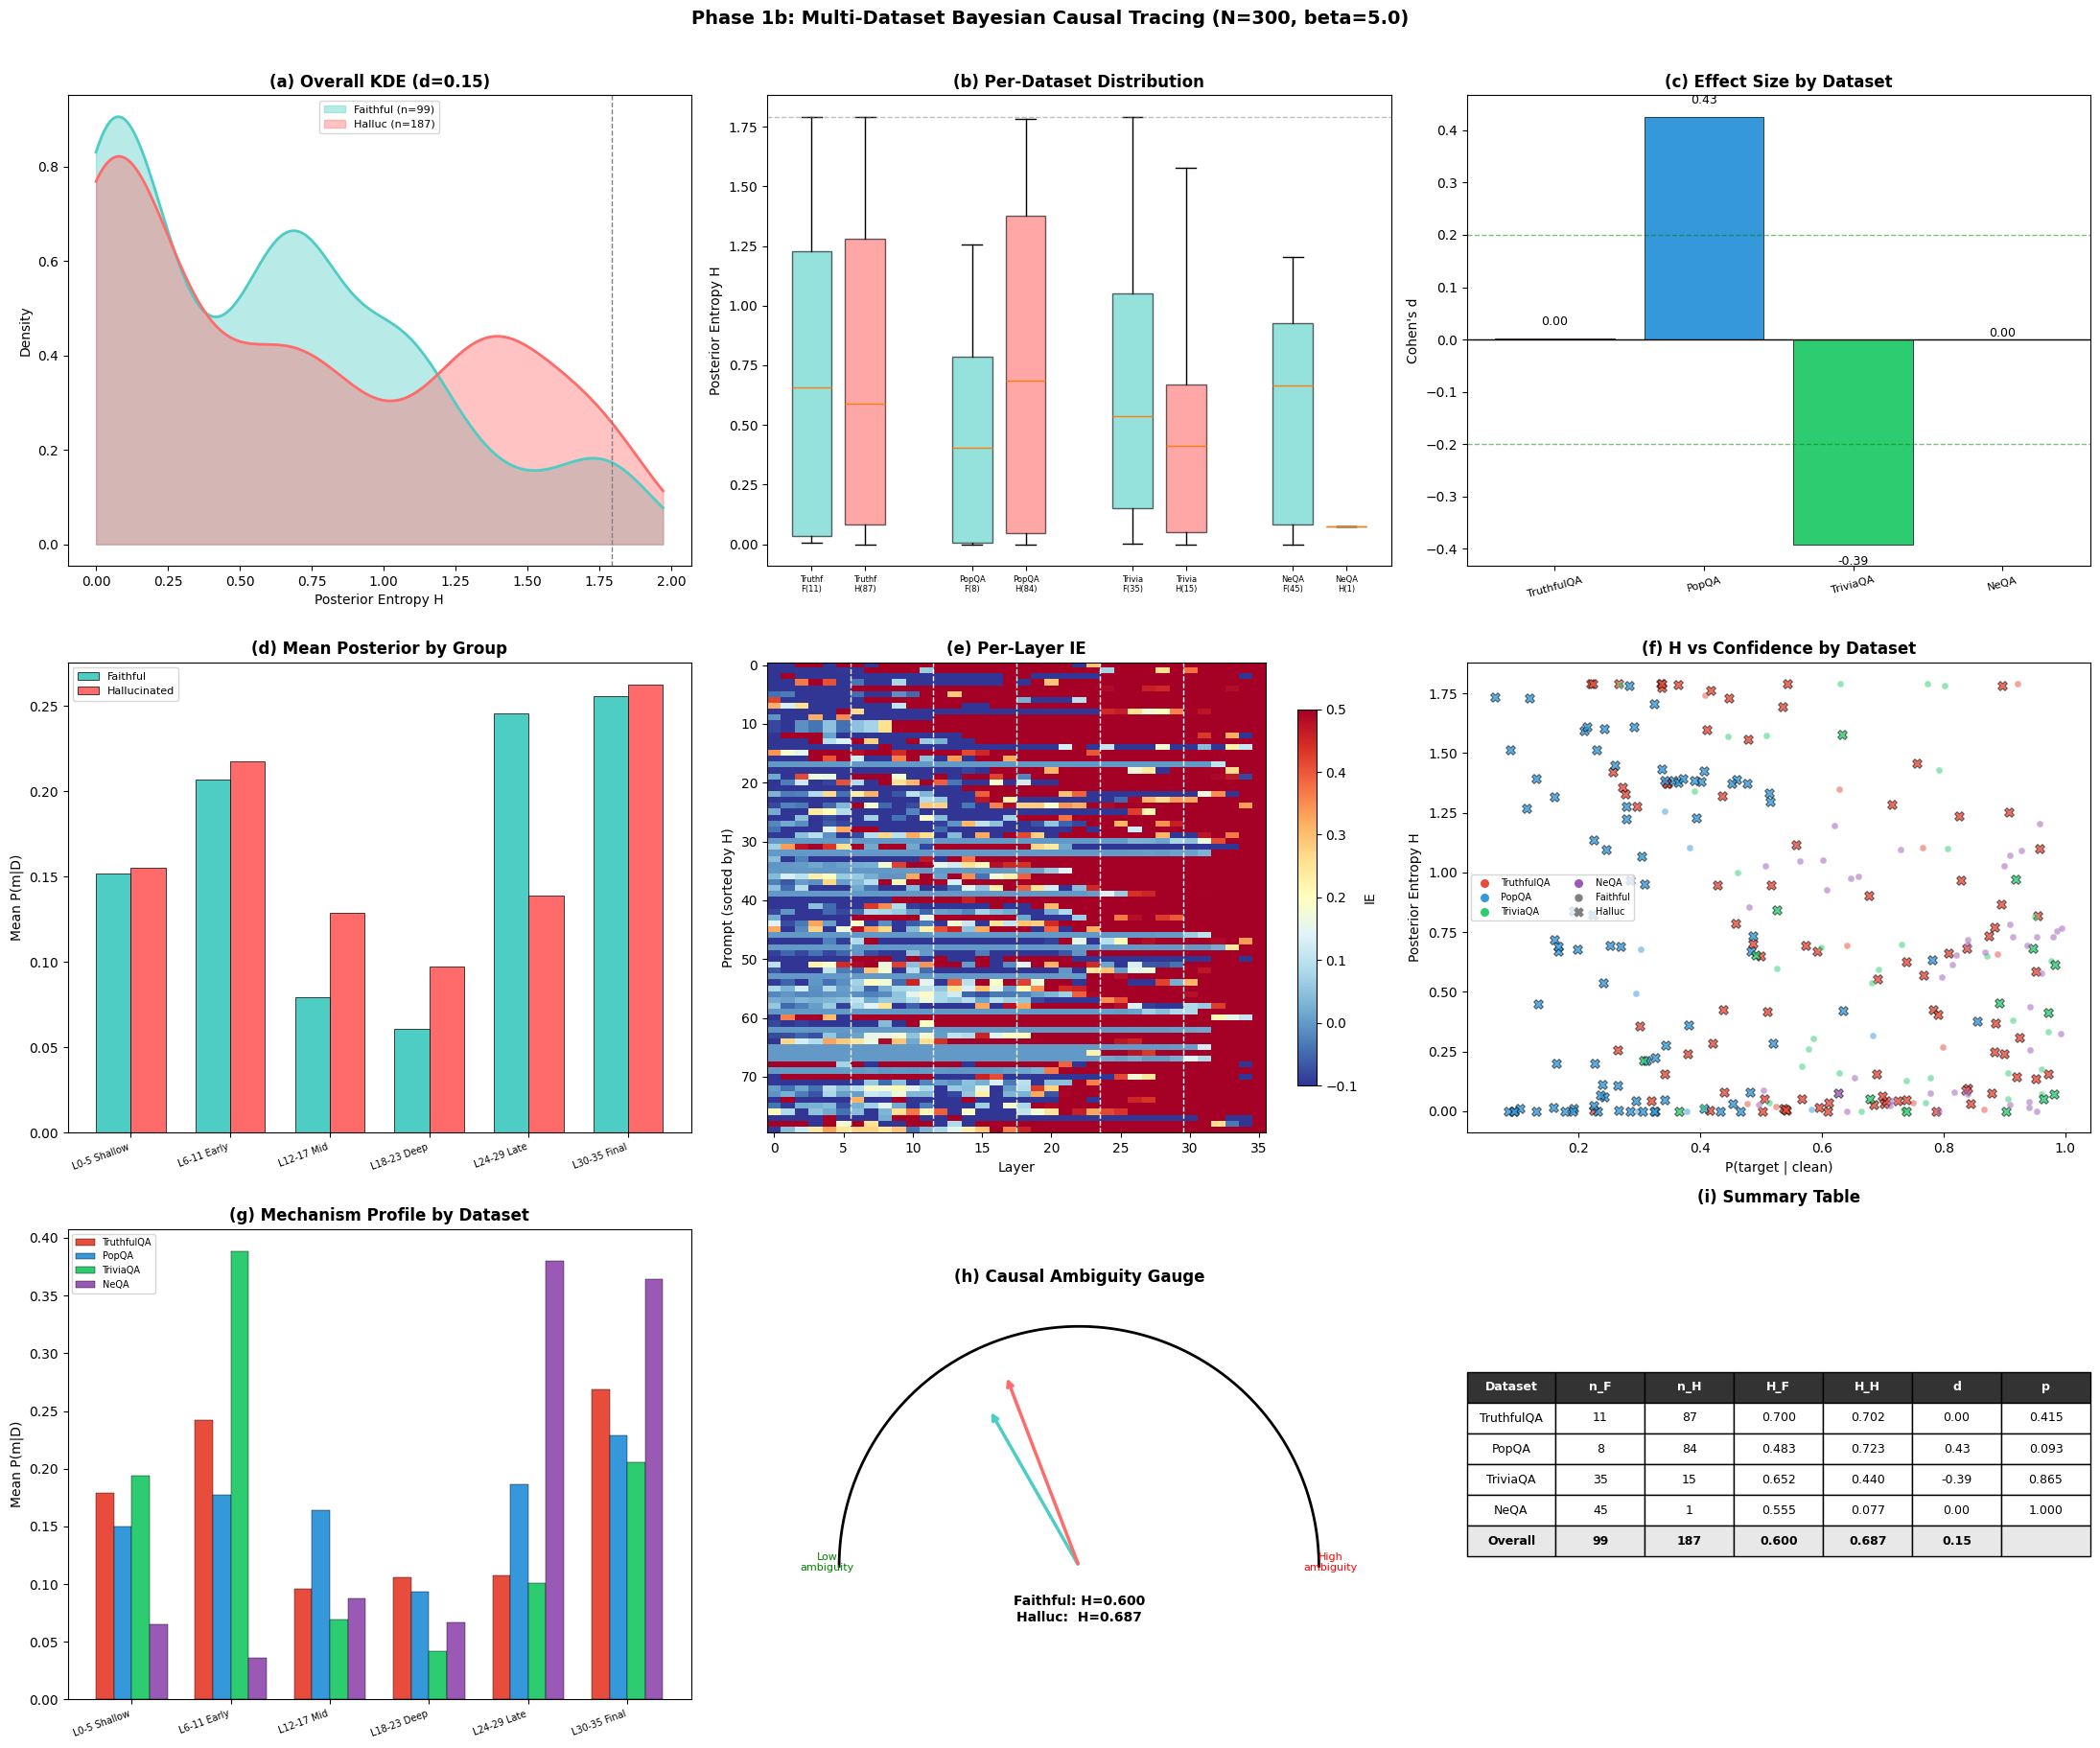

Saved main_results.png


In [6]:
colors_f = '#4ECDC4'
colors_h = '#FF6B6B'
ds_colors = {'TruthfulQA': '#E74C3C', 'PopQA': '#3498DB', 'TriviaQA': '#2ECC71', 'NeQA': '#9B59B6'}
mech_colors = ['#FF6B6B', '#FFE66D', '#4ECDC4', '#95E1D3', '#A8D8EA', '#DDA0DD']

fig = plt.figure(figsize=(22, 18))

# ── (a) Overall KDE ──
ax1 = fig.add_subplot(3, 3, 1)
x_range = np.linspace(0, H_max * 1.1, 200)
if len(H_faithful) > 2:
    kde_f = stats.gaussian_kde(H_faithful, bw_method=0.3)
    ax1.fill_between(x_range, kde_f(x_range), alpha=0.4, color=colors_f, label=f'Faithful (n={len(H_faithful)})')
    ax1.plot(x_range, kde_f(x_range), color=colors_f, lw=2)
if len(H_halluc) > 2:
    kde_h = stats.gaussian_kde(H_halluc, bw_method=0.3)
    ax1.fill_between(x_range, kde_h(x_range), alpha=0.4, color=colors_h, label=f'Halluc (n={len(H_halluc)})')
    ax1.plot(x_range, kde_h(x_range), color=colors_h, lw=2)
ax1.axvline(H_max, color='grey', ls='--', lw=1)
ax1.set_xlabel('Posterior Entropy H')
ax1.set_ylabel('Density')
ax1.set_title(f'(a) Overall KDE (d={cohen_d:.2f})', fontweight='bold')
ax1.legend(fontsize=8)

# ── (b) Per-Dataset Box Plots ──
ax2 = fig.add_subplot(3, 3, 2)
box_data = []
box_labels = []
box_positions = []
pos = 0
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    ds_mask = ds_labels == ds_name
    mf = ds_mask & is_faithful & significant
    mh = ds_mask & (~is_faithful) & significant
    Hf_ds = entropies[mf]
    Hh_ds = entropies[mh]
    if len(Hf_ds) > 0:
        box_data.append(Hf_ds)
        box_positions.append(pos)
        box_labels.append(f'{ds_name[:6]}\nF({len(Hf_ds)})')
    if len(Hh_ds) > 0:
        box_data.append(Hh_ds)
        box_positions.append(pos + 0.6)
        box_labels.append(f'{ds_name[:6]}\nH({len(Hh_ds)})')
    pos += 1.8

if box_data:
    bp = ax2.boxplot(box_data, positions=box_positions, widths=0.45, patch_artist=True)
    color_idx = 0
    for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
        ds_mask = ds_labels == ds_name
        mf = ds_mask & is_faithful & significant
        mh = ds_mask & (~is_faithful) & significant
        if len(entropies[mf]) > 0:
            bp['boxes'][color_idx].set_facecolor(colors_f)
            bp['boxes'][color_idx].set_alpha(0.6)
            color_idx += 1
        if len(entropies[mh]) > 0:
            bp['boxes'][color_idx].set_facecolor(colors_h)
            bp['boxes'][color_idx].set_alpha(0.6)
            color_idx += 1
    ax2.set_xticks(box_positions)
    ax2.set_xticklabels(box_labels, fontsize=6, rotation=0)
ax2.set_ylabel('Posterior Entropy H')
ax2.set_title('(b) Per-Dataset Distribution', fontweight='bold')
ax2.axhline(H_max, color='grey', ls='--', lw=1, alpha=0.5)

# ── (c) Cohen's d per dataset ──
ax3 = fig.add_subplot(3, 3, 3)
ds_names_plot = list(per_ds_results.keys())
ds_d = [per_ds_results[d]['d'] for d in ds_names_plot]
ds_p = [per_ds_results[d]['p'] for d in ds_names_plot]
bars = ax3.bar(range(len(ds_names_plot)), ds_d, color=[ds_colors[d] for d in ds_names_plot], edgecolor='black', lw=0.5)
ax3.axhline(0, color='black', lw=1)
ax3.axhline(0.2, color='green', ls='--', lw=1, alpha=0.5, label='small effect')
ax3.axhline(-0.2, color='green', ls='--', lw=1, alpha=0.5)
ax3.set_xticks(range(len(ds_names_plot)))
ax3.set_xticklabels(ds_names_plot, fontsize=8, rotation=15)
ax3.set_ylabel("Cohen's d")
ax3.set_title("(c) Effect Size by Dataset", fontweight='bold')
for i, (d, p) in enumerate(zip(ds_d, ds_p)):
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
    ax3.text(i, d + 0.02 * np.sign(d), f'{d:.2f}{sig}', ha='center', va='bottom' if d>=0 else 'top', fontsize=9)

# ── (d) Mean Posterior (faithful vs halluc) ──
ax4 = fig.add_subplot(3, 3, 4)
x = np.arange(K)
w = 0.35
ax4.bar(x - w/2, mean_post_f, w, color=colors_f, edgecolor='black', lw=0.5, label='Faithful')
ax4.bar(x + w/2, mean_post_h, w, color=colors_h, edgecolor='black', lw=0.5, label='Hallucinated')
ax4.set_xticks(x)
ax4.set_xticklabels(MECH_NAMES, fontsize=7, rotation=20, ha='right')
ax4.set_ylabel('Mean P(m|D)')
ax4.set_title('(d) Mean Posterior by Group', fontweight='bold')
ax4.legend(fontsize=8)

# ── (e) IE Heatmap ──
ax5 = fig.add_subplot(3, 3, 5)
sig_idx = np.where(significant)[0]
if len(sig_idx) > 0:
    order = sig_idx[np.argsort(entropies[sig_idx])]
    n_show = min(80, len(order))
    ie_show = IE_per_layer[order[:n_show]]
    im = ax5.imshow(ie_show, aspect='auto', cmap='RdYlBu_r', vmin=-0.1, vmax=0.5)
    ax5.set_xlabel('Layer')
    ax5.set_ylabel('Prompt (sorted by H)')
    ax5.set_title('(e) Per-Layer IE', fontweight='bold')
    plt.colorbar(im, ax=ax5, shrink=0.8, label='IE')
    for boundary in [6, 12, 18, 24, 30]:
        ax5.axvline(boundary - 0.5, color='white', lw=1, ls='--')

# ── (f) Scatter: H vs p_clean, colored by dataset ──
ax6 = fig.add_subplot(3, 3, 6)
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    ds_mask = (ds_labels == ds_name) & significant
    ds_f = ds_mask & is_faithful
    ds_h = ds_mask & (~is_faithful)
    if ds_f.sum() > 0:
        ax6.scatter(p_clean_arr[ds_f], entropies[ds_f], c=ds_colors[ds_name], 
                    alpha=0.5, s=25, marker='o', edgecolors='white', lw=0.3)
    if ds_h.sum() > 0:
        ax6.scatter(p_clean_arr[ds_h], entropies[ds_h], c=ds_colors[ds_name], 
                    alpha=0.8, s=50, marker='X', edgecolors='black', lw=0.5)
# Legend
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    ax6.scatter([], [], c=ds_colors[ds_name], label=ds_name, s=30)
ax6.scatter([], [], c='grey', marker='o', label='Faithful', s=25)
ax6.scatter([], [], c='grey', marker='X', label='Halluc', s=40)
ax6.set_xlabel('P(target | clean)')
ax6.set_ylabel('Posterior Entropy H')
ax6.set_title('(f) H vs Confidence by Dataset', fontweight='bold')
ax6.legend(fontsize=7, ncol=2)

# ── (g) Per-dataset posterior profiles ──
ax7 = fig.add_subplot(3, 3, 7)
x = np.arange(K)
w = 0.18
for di, ds_name in enumerate(['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']):
    ds_mask = (ds_labels == ds_name) & significant
    if ds_mask.sum() > 0:
        mp = posteriors[ds_mask].mean(axis=0)
        ax7.bar(x + di * w - 1.5*w, mp, w, color=ds_colors[ds_name], edgecolor='black', lw=0.3, label=ds_name)
ax7.set_xticks(x)
ax7.set_xticklabels(MECH_NAMES, fontsize=7, rotation=20, ha='right')
ax7.set_ylabel('Mean P(m|D)')
ax7.set_title('(g) Mechanism Profile by Dataset', fontweight='bold')
ax7.legend(fontsize=7)

# ── (h) Gauge ──
ax8 = fig.add_subplot(3, 3, 8)
H_mean_f = H_faithful.mean() if len(H_faithful) > 0 else 0
H_mean_h = H_halluc.mean() if len(H_halluc) > 0 else 0
theta = np.linspace(np.pi, 0, 200)
ax8.plot(np.cos(theta), np.sin(theta), 'k-', lw=2)
frac_f = H_mean_f / H_max if H_max > 0 else 0
angle_f = np.pi * (1 - frac_f)
ax8.annotate('', xy=(0.75*np.cos(angle_f), 0.75*np.sin(angle_f)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=colors_f, lw=2.5))
frac_h = H_mean_h / H_max if H_max > 0 else 0
angle_h = np.pi * (1 - frac_h)
ax8.annotate('', xy=(0.85*np.cos(angle_h), 0.85*np.sin(angle_h)), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color=colors_h, lw=2.5))
ax8.text(0, -0.12, f'Faithful: H={H_mean_f:.3f}\nHalluc:  H={H_mean_h:.3f}',
         ha='center', va='top', fontsize=10, fontweight='bold')
ax8.text(-1.05, -0.02, 'Low\nambiguity', ha='center', fontsize=8, color='green')
ax8.text(1.05, -0.02, 'High\nambiguity', ha='center', fontsize=8, color='red')
ax8.set_xlim(-1.3, 1.3); ax8.set_ylim(-0.3, 1.15)
ax8.set_aspect('equal'); ax8.axis('off')
ax8.set_title('(h) Causal Ambiguity Gauge', fontweight='bold')

# ── (i) Summary table ──
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
table_data = [['Dataset', 'n_F', 'n_H', 'H_F', 'H_H', 'd', 'p']]
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    r = per_ds_results[ds_name]
    sig = '***' if r['p']<0.001 else '**' if r['p']<0.01 else '*' if r['p']<0.05 else ''
    table_data.append([ds_name, str(r['n_f']), str(r['n_h']),
                       f"{r['H_f']:.3f}", f"{r['H_h']:.3f}",
                       f"{r['d']:.2f}", f"{r['p']:.3f}{sig}"])
table_data.append(['Overall', str(mask_f.sum()), str(mask_h.sum()),
                    f"{H_faithful.mean():.3f}", f"{H_halluc.mean():.3f}",
                    f"{cohen_d:.2f}", ''])
tbl = ax9.table(cellText=table_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#333333')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == len(table_data) - 1:
        cell.set_facecolor('#E8E8E8')
        cell.set_text_props(fontweight='bold')
ax9.set_title('(i) Summary Table', fontweight='bold', pad=20)

fig.suptitle(f'Phase 1b: Multi-Dataset Bayesian Causal Tracing (N={N}, beta={beta_default})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/workspace/Data/bayesian_phase1b/main_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved main_results.png")

DETAILED STATISTICAL TESTS

Overall (N_f=99, N_h=187):
  Mann-Whitney U = 9737.0, p = 0.235344
  KS D = 0.1783, p = 0.028237
  Welch t = 1.251, p = 0.212349
  AUC = 0.526
  Cohen d = 0.152

TruthfulQA (N_f=11, N_h=87):
  Mann-Whitney p = 0.4153
  Welch t = 0.007, p = 0.9942

PopQA (N_f=8, N_h=84):
  Mann-Whitney p = 0.0929
  Welch t = 1.272, p = 0.2344

TriviaQA (N_f=35, N_h=15):
  Mann-Whitney p = 0.8645
  Welch t = -1.348, p = 0.1863

NeQA (N_f=45, N_h=1):
  Insufficient samples for test

BETA SENSITIVITY (all datasets)


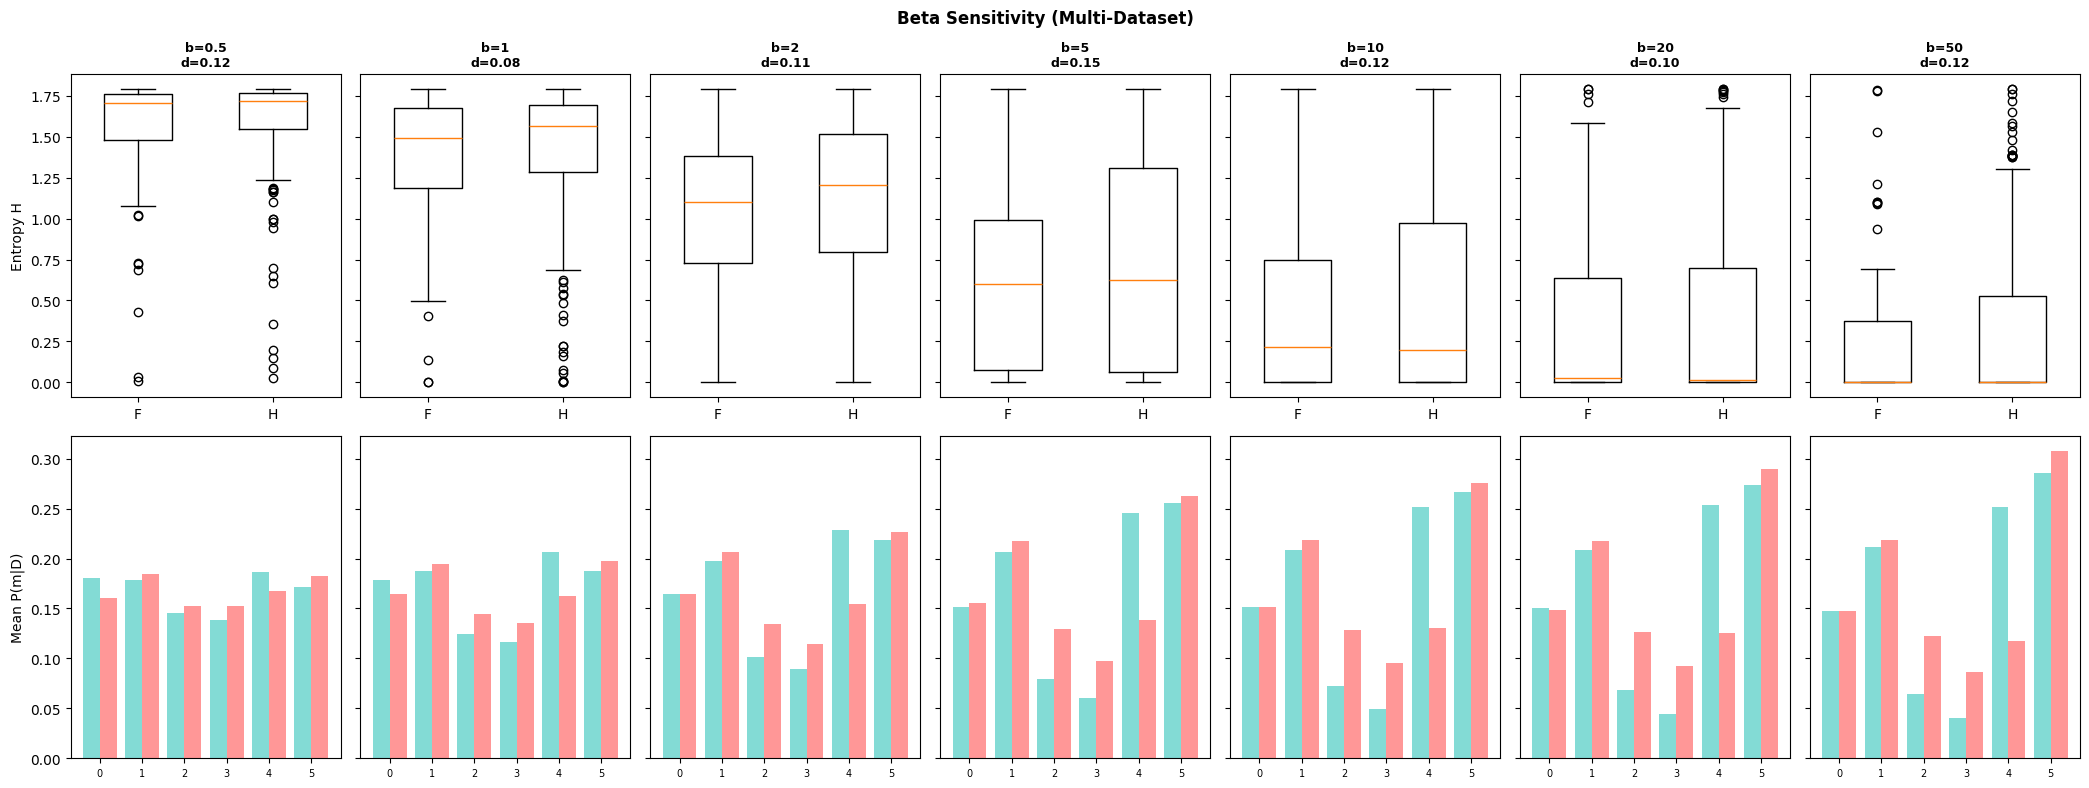


 beta   Cohen d     p-value   H_faith   H_halluc
----------------------------------------------
  0.5     0.120    0.138618    1.5479     1.5890  n.s.
  1.0     0.078    0.098103    1.3588     1.3924  n.s.
  2.0     0.113    0.093754    1.0355     1.0924  n.s.
  5.0     0.152    0.235344    0.5997     0.6871  n.s.
 10.0     0.117    0.433758    0.4429     0.5082  n.s.
 20.0     0.099    0.502398    0.3440     0.3958  n.s.
 50.0     0.115    0.576271    0.2435     0.2975  n.s.


In [7]:
print("=" * 60)
print("DETAILED STATISTICAL TESTS")
print("=" * 60)

# Overall tests
if len(H_faithful) > 1 and len(H_halluc) > 1:
    U, p_mw = stats.mannwhitneyu(H_halluc, H_faithful, alternative='greater')
    ks_stat, p_ks = stats.ks_2samp(H_faithful, H_halluc)
    t_stat, p_t = stats.ttest_ind(H_halluc, H_faithful, equal_var=False)
    from sklearn.metrics import roc_auc_score
    y_true = np.concatenate([np.zeros(mask_f.sum()), np.ones(mask_h.sum())])
    y_score = np.concatenate([entropies[mask_f], entropies[mask_h]])
    auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true))==2 else 0.5
    
    print(f"\nOverall (N_f={mask_f.sum()}, N_h={mask_h.sum()}):")
    print(f"  Mann-Whitney U = {U:.1f}, p = {p_mw:.6f}")
    print(f"  KS D = {ks_stat:.4f}, p = {p_ks:.6f}")
    print(f"  Welch t = {t_stat:.3f}, p = {p_t:.6f}")
    print(f"  AUC = {auc:.3f}")
    print(f"  Cohen d = {cohen_d:.3f}")

# Per-dataset tests
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    ds_mask = ds_labels == ds_name
    mf = ds_mask & is_faithful & significant
    mh = ds_mask & (~is_faithful) & significant
    Hf_ds = entropies[mf]
    Hh_ds = entropies[mh]
    print(f"\n{ds_name} (N_f={mf.sum()}, N_h={mh.sum()}):")
    if len(Hf_ds) > 1 and len(Hh_ds) > 1:
        U_ds, p_ds = stats.mannwhitneyu(Hh_ds, Hf_ds, alternative='greater')
        t_ds, pt_ds = stats.ttest_ind(Hh_ds, Hf_ds, equal_var=False)
        print(f"  Mann-Whitney p = {p_ds:.4f}")
        print(f"  Welch t = {t_ds:.3f}, p = {pt_ds:.4f}")
    else:
        print(f"  Insufficient samples for test")

# Beta sensitivity
print(f"\n{'='*60}")
print("BETA SENSITIVITY (all datasets)")
print(f"{'='*60}")

beta_values = [0.5, 1, 2, 5, 10, 20, 50]
fig, axes = plt.subplots(2, len(beta_values), figsize=(3*len(beta_values), 8), sharey='row')
sens_results = []

for bi, beta_val in enumerate(beta_values):
    post_b, ent_b = compute_posteriors_and_entropy(IE, beta_val)
    Hf = ent_b[mask_f]
    Hh = ent_b[mask_h]
    sp_b = np.sqrt((Hf.var(ddof=1) + Hh.var(ddof=1)) / 2) if (len(Hf)>1 and len(Hh)>1) else 1e-10
    d_b = (Hh.mean() - Hf.mean()) / sp_b if sp_b > 1e-10 else 0
    _, p_b = stats.mannwhitneyu(Hh, Hf, alternative='greater') if (len(Hf)>1 and len(Hh)>1) else (0, 1)
    sens_results.append((beta_val, d_b, p_b, Hf.mean(), Hh.mean()))
    
    ax = axes[0, bi]
    if len(Hf) > 0 and len(Hh) > 0:
        ax.boxplot([Hf, Hh], labels=['F', 'H'], widths=0.5)
    ax.set_title(f'b={beta_val}\nd={d_b:.2f}', fontsize=9, fontweight='bold')
    if bi == 0: ax.set_ylabel('Entropy H')
    
    ax2 = axes[1, bi]
    mf_p = post_b[mask_f].mean(axis=0) if mask_f.sum() > 0 else np.zeros(K)
    mh_p = post_b[mask_h].mean(axis=0) if mask_h.sum() > 0 else np.zeros(K)
    xb = np.arange(K)
    ax2.bar(xb - 0.2, mf_p, 0.4, color=colors_f, alpha=0.7)
    ax2.bar(xb + 0.2, mh_p, 0.4, color=colors_h, alpha=0.7)
    ax2.set_xticks(xb)
    ax2.set_xticklabels([str(i) for i in range(K)], fontsize=7)
    if bi == 0: ax2.set_ylabel('Mean P(m|D)')

fig.suptitle('Beta Sensitivity (Multi-Dataset)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/Data/bayesian_phase1b/beta_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'beta':>5s}  {'Cohen d':>8s}  {'p-value':>10s}  {'H_faith':>8s}  {'H_halluc':>9s}")
print("-" * 46)
for beta_val, d_b, p_b, hf, hh in sens_results:
    sig = '***' if p_b<0.001 else '**' if p_b<0.01 else '*' if p_b<0.05 else 'n.s.'
    print(f"{beta_val:5.1f}  {d_b:8.3f}  {p_b:10.6f}  {hf:8.4f}  {hh:9.4f}  {sig}")

In [8]:
# Save all results
np.savez('/workspace/Data/bayesian_phase1b/phase1b_results.npz',
    is_faithful=is_faithful,
    significant=significant,
    ds_labels=ds_labels,
    p_clean=p_clean_arr,
    p_corrupt=p_corrupt_arr,
    target_tokens=target_tokens,
    IE=IE, IE_raw=IE_raw, IE_full=IE_full,
    IE_per_layer=IE_per_layer,
    posteriors=posteriors,
    entropies=entropies,
    beta_default=beta_default,
    n_prompts=N, n_mechanisms=K,
    mechanism_names=np.array(MECH_NAMES),
)

# Also save per-dataset summaries as JSON
import json
summary = {
    'phase': '1b',
    'model': 'Qwen3-8B-Q4_K_M',
    'n_prompts': int(N),
    'beta': beta_default,
    'overall': {
        'n_faithful': int(mask_f.sum()),
        'n_hallucinated': int(mask_h.sum()),
        'H_faithful': float(H_faithful.mean()) if len(H_faithful)>0 else None,
        'H_hallucinated': float(H_halluc.mean()) if len(H_halluc)>0 else None,
        'cohen_d': float(cohen_d),
    },
    'per_dataset': {}
}
for ds_name, r in per_ds_results.items():
    summary['per_dataset'][ds_name] = {k: float(v) if isinstance(v, (np.floating, float)) else int(v) for k, v in r.items()}

with open('/workspace/Data/bayesian_phase1b/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("PHASE 1b FINAL RESULTS")
print("=" * 60)
print(f"\nDataset: {N} prompts across 4 benchmarks")
print(f"Significant: {mask_f.sum()} faithful, {mask_h.sum()} hallucinated\n")
print(f"{'Dataset':>14s}  {'n_F':>4s}  {'n_H':>4s}  {'H_F':>7s}  {'H_H':>7s}  {'d':>7s}  {'p':>8s}")
print("-" * 56)
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    r = per_ds_results[ds_name]
    sig = '*' if r['p']<0.05 else ''
    print(f"{ds_name:>14s}  {r['n_f']:4d}  {r['n_h']:4d}  {r['H_f']:7.4f}  {r['H_h']:7.4f}  {r['d']:7.3f}  {r['p']:7.4f} {sig}")
print(f"{'OVERALL':>14s}  {mask_f.sum():4d}  {mask_h.sum():4d}  {H_faithful.mean():7.4f}  {H_halluc.mean():7.4f}  {cohen_d:7.3f}")

if cohen_d > 0.5:
    verdict = "STRONG support for H1"
elif cohen_d > 0.2:
    verdict = "MODERATE support for H1"
elif cohen_d > 0:
    verdict = "WEAK support for H1"
else:
    verdict = "H1 NOT supported (d < 0)"
print(f"\nVerdict: {verdict}")
print(f"\nSaved to /workspace/Data/bayesian_phase1b/")

PHASE 1b FINAL RESULTS

Dataset: 300 prompts across 4 benchmarks
Significant: 99 faithful, 187 hallucinated

       Dataset   n_F   n_H      H_F      H_H        d         p
--------------------------------------------------------
    TruthfulQA    11    87   0.7004   0.7020    0.002   0.4153 
         PopQA     8    84   0.4825   0.7230    0.426   0.0929 
      TriviaQA    35    15   0.6524   0.4399   -0.391   0.8645 
          NeQA    45     1   0.5550   0.0770    0.000   1.0000 
       OVERALL    99   187   0.5997   0.6871    0.152

Verdict: WEAK support for H1

Saved to /workspace/Data/bayesian_phase1b/
